# Part 0 — Data Preparation & HW2 Bridge




In [1]:
# Installing Hugging Face datasets
!pip install datasets==3.6.0 --quiet
!pip install git+https://github.com/MultimodalUniverse/MultimodalUniverse.git --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from datasets import load_dataset
# Import pandas
import pandas as pd
# Import numpy
import numpy as np
# Import the plotting functions from matplotlib
import matplotlib.pyplot as plt
import os
import seaborn as sns
from datasets import load_dataset_builder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import skew

In [3]:
dset_plasticc = load_dataset("MultimodalUniverse/plasticc",
                       streaming=True,
                       split='train')
dset_plasticc = dset_plasticc.with_format("numpy")
dset_iterator = iter(dset_plasticc)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.90k [00:00<?, ?B/s]

In [4]:
import numpy as np

# Trackers for our analysis
sequence_lengths = []
all_flux_values = []

# We iterate through the dataset just like in Homework 2
for ex in dset_plasticc:
    lc = ex['lightcurve']

    # 1. Inspect Sequence Lengths (Number of time steps for this object)
    # lc['flux'] contains the full sequence of observations
    seq_length = len(lc['flux'])
    sequence_lengths.append(seq_length)

    # 2. Collect flux values to analyze the numerical range
    all_flux_values.extend(lc['flux'])

# Convert to numpy arrays for fast statistical analysis
sequence_lengths = np.array(sequence_lengths)
all_flux_values = np.array(all_flux_values)

# --- Output the Inspection Results ---
print("=== SEQUENCE LENGTH ANALYSIS (Temporal Dimension T) ===")
print(f"Total Objects Inspected: {len(sequence_lengths)}")
print(f"Minimum Time Steps (T_min): {sequence_lengths.min()}")
print(f"Maximum Time Steps (T_max): {sequence_lengths.max()}")
print(f"Average Time Steps (T_mean): {sequence_lengths.mean():.2f}")
print(f"Median Time Steps: {np.median(sequence_lengths)}")

print("\n=== FLUX VALUE ANALYSIS (Feature Scale) ===")
print(f"Global Minimum Flux: {all_flux_values.min():.4f}")
print(f"Global Maximum Flux: {all_flux_values.max():.4f}")
print(f"Mean Flux: {all_flux_values.mean():.4f}")
print(f"Standard Deviation of Flux: {all_flux_values.std():.4f}")

=== SEQUENCE LENGTH ANALYSIS (Temporal Dimension T) ===
Total Objects Inspected: 7848
Minimum Time Steps (T_min): 330
Maximum Time Steps (T_max): 2112
Average Time Steps (T_mean): 1118.70
Median Time Steps: 846.0

=== FLUX VALUE ANALYSIS (Feature Scale) ===
Global Minimum Flux: -1149388.3750
Global Maximum Flux: 2432808.7500
Mean Flux: 3.6008
Standard Deviation of Flux: 1361.3979


3.1 Modality, Split & Pre-processing

1. Modality & Input Description

    In our analysis, we select the multi-band time-series light curves modality. Instead of flattening the temporal dimension into static features (like mean or max), we are preserving the sequential nature of the observations.

    Based on our prior dataset inspection, a single input example is characterized as follows:
    * Shape: A raw single input is a 2D sequence of shape (T, 5), where T represents the number of time steps (observations) and 5 represents the photometric passbands (u, g, r, i, z). Because our inspection revealed that sequence lengths vary from $T_{min} = 330$ to $T_{max} = 2112$, we will post-pad all sequences to achieve a uniform tensor shape of (2112, 5) per object.

    * Units: The time axis represents observation epochs (typically measured in Modified Julian Date, MJD), and the features represent the observed luminosity in Flux (typically microJanskys, $\mu$Jy).

    * Value Range: Our analysis revealed an extreme value range, from a minimum flux of $-1,149,388.37$ to a maximum of $2,432,808.75$. The negative values are a standard artifact of subtracting background sky noise. However, the massive standard deviation ($\sim 1361.4$) confirms that we must strictly normalize this data before it hits our neural network.


In [5]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence

# ==========================================
# 0. DO NOT ASSUME DATA IS IN MEMORY
# Extract native asynchronous sequences from the IterableDataset
# ==========================================
X_raw_list = []
y_raw_list = []


for ex in dset_plasticc:
    lc = ex['lightcurve']

    # We explicitly extract the 3 native 1D arrays for each object
    time_arr = np.array(lc['time'])
    flux_arr = np.array(lc['flux'])
    band_arr = np.array(lc['band']) # strings

    # Package them together for this object
    X_raw_list.append({
        'time': time_arr,
        'flux': flux_arr,
        'band': band_arr
    })
    y_raw_list.append(ex['hostgal_specz'])


# ==========================================
# 1. FIX RANDOM SEED & SPLIT (Exact HW2 Logic)
# ==========================================
RANDOM_SEED = 42

X_train_raw, X_temp_raw, y_train, y_temp_raw = train_test_split(
    X_raw_list, y_raw_list,
    test_size=0.30,
    random_state=RANDOM_SEED
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp_raw,
    test_size=0.50,
    random_state=RANDOM_SEED
)

print(f"Train: {len(X_train_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}")

# ==========================================
# 2. ASSUMPTION-FREE PER-BAND NORMALIZATION
# ==========================================

all_unique_bands = ['u', 'g', 'r', 'i', 'z','Y']

# Sort them to ensure consistent ordering
bands_present = sorted(list(all_unique_bands))
num_bands = len(bands_present)

# Create a mapping from the string band to a numerical tensor column index
# e.g., {'g': 0, 'i': 1, 'r': 2, 'u': 3, 'y': 4, 'z': 5}
band_to_col = {band_str: idx for idx, band_str in enumerate(bands_present)}

train_stats = {}

# We gather every single flux value from the training set, separated by band
for b in bands_present:
    band_fluxes = []
    for obj in X_train_raw:
        # Get fluxes only where the band equals 'b'
        mask = (obj['band'] == b)
        band_fluxes.extend(obj['flux'][mask])

    # Calculate mean and std for this specific band
    band_fluxes = np.array(band_fluxes)
    if len(band_fluxes) > 0:
        mu = np.mean(band_fluxes)
        std = np.std(band_fluxes)
        train_stats[b] = {'mean': mu, 'std': std if std > 0 else 1.0}
    else:
        train_stats[b] = {'mean': 0.0, 'std': 1.0}

# ==========================================
# 3. BUILD AND PAD NATIVE TENSORS FOR LSTM
# ==========================================

def process_and_pad(raw_split):
    """
    Takes a raw split, applies train scaling, maps to a 2D matrix (TimeSteps x num_bands),
    and pads them into a uniform 3D PyTorch tensor.
    """
    processed_tensors = []

    for obj in raw_split:
        T_i = len(obj['flux'])

        # FIX 1: Change hardcoded 6 to `num_bands` (which is 5 based on our discovery)
        obj_matrix = np.zeros((T_i, num_bands), dtype=np.float32)

        for step in range(T_i):
            b = obj['band'][step] # This is a string, e.g., 'g'
            f_raw = obj['flux'][step]

            # Apply our Z-score scaling strictly using train statistics
            f_scaled = (f_raw - train_stats[b]['mean']) / train_stats[b]['std']

            # FIX 2: Convert the string band to an integer column index
            col_idx = band_to_col[b]

            # Place the scaled flux into the correct integer column for this time step
            obj_matrix[step, col_idx] = f_scaled

        processed_tensors.append(torch.tensor(obj_matrix))

    # pad_sequence handles the varying T_i lengths, padding to the max length in the dataset
    padded_batch = pad_sequence(processed_tensors, batch_first=True, padding_value=0.0)
    return padded_batch

    processed_tensors.append(torch.tensor(obj_matrix))

    # pad_sequence handles the varying T_i lengths, padding to the max length in the dataset
    # batch_first=True makes the shape: (Batch_size, T_max, 6)
    padded_batch = pad_sequence(processed_tensors, batch_first=True, padding_value=0.0)
    return padded_batch

# Apply the processing
X_train_tensor = process_and_pad(X_train_raw)
X_val_tensor = process_and_pad(X_val_raw)
X_test_tensor = process_and_pad(X_test_raw)

# Convert targets to tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("\n=== FINAL Z-SCORE NORMALIZED LSTM INPUT SHAPES ===")
print(f"X_train: {X_train_tensor.shape} | y_train: {y_train_tensor.shape}")
print(f"X_val:   {X_val_tensor.shape}   | y_val:   {y_val_tensor.shape}")
print(f"X_test:  {X_test_tensor.shape}   | y_test:  {y_test_tensor.shape}")


print("=== DISPLAYING 3 EXAMPLE INPUT TENSORS ===")

for i in range(3):
    example = X_train_tensor[i]

    print(f"\n--- Example {i+1} ---")
    print(f"Shape: {example.shape} (Sequence Length: {example.shape[0]}, Features/Bands: {example.shape[1]})")
    print("Units: Z-score Scaled Flux")

    # We round to 4 decimal places just so it prints cleanly on the screen
    print("\nFirst 5 time steps (Actual Observations):")
    # Using numpy formatting options for cleaner tensor printing
    np.set_printoptions(precision=4, suppress=True)
    print(example[:5].numpy())

    print("\nLast 2 time steps (Demonstrating the 0.0 Padding):")
    print(example[-2:].numpy())
    print("-" * 40)

Train: 5493 | Val: 1177 | Test: 1178

=== FINAL Z-SCORE NORMALIZED LSTM INPUT SHAPES ===
X_train: torch.Size([5493, 2112, 6]) | y_train: torch.Size([5493, 1])
X_val:   torch.Size([1177, 2112, 6])   | y_val:   torch.Size([1177, 1])
X_test:  torch.Size([1178, 2112, 6])   | y_test:  torch.Size([1178, 1])
=== DISPLAYING 3 EXAMPLE INPUT TENSORS ===

--- Example 1 ---
Shape: torch.Size([2112, 6]) (Sequence Length: 2112, Features/Bands: 6)
Units: Z-score Scaled Flux

First 5 time steps (Actual Observations):
[[ 0.      0.      0.      0.     -0.0008  0.    ]
 [ 0.      0.      0.      0.     -0.0008  0.    ]
 [ 0.      0.      0.      0.     -0.0012  0.    ]
 [ 0.      0.      0.      0.     -0.0001  0.    ]
 [ 0.      0.      0.      0.     -0.0006  0.    ]]

Last 2 time steps (Demonstrating the 0.0 Padding):
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
----------------------------------------

--- Example 2 ---
Shape: torch.Size([2112, 6]) (Sequence Length: 2112, Features/Bands: 6)
Units: Z-s

In [6]:
import torch

def verify_tensor_normalization(tensor, split_name):
    print(f"\n=== {split_name} Set Normalization Verification ===")

    # Iterate through each discovered band using our dynamic dictionary
    for b_str, col_idx in band_to_col.items():
        # Extract all values across all batches and time steps for this specific band
        band_values = tensor[:, :, col_idx]

        # Filter out the padding (0.0).
        # Note: Since flux is continuous, the chance of a true scaled flux being exactly 0.000000 is statistically virtually zero.
        valid_values = band_values[band_values != 0.0]

        if len(valid_values) > 0:
            mean_val = valid_values.mean().item()
            std_val = valid_values.std().item()

            print(f"Band '{b_str}' (Col {col_idx}): Mean = {mean_val:>7.4f} | Std = {std_val:>7.4f}")
        else:
            print(f"Band '{b_str}' (Col {col_idx}): No valid data found.")

# Run the verification on Train and Validation tensors
verify_tensor_normalization(X_train_tensor, "TRAINING")
verify_tensor_normalization(X_val_tensor, "VALIDATION")


=== TRAINING Set Normalization Verification ===
Band 'Y' (Col 0): No valid data found.
Band 'g' (Col 1): Mean =  0.0000 | Std =  1.0000
Band 'i' (Col 2): Mean = -0.0000 | Std =  1.0000
Band 'r' (Col 3): Mean = -0.0000 | Std =  1.0000
Band 'u' (Col 4): Mean =  0.0000 | Std =  1.0000
Band 'z' (Col 5): Mean = -0.0000 | Std =  1.0000

=== VALIDATION Set Normalization Verification ===
Band 'Y' (Col 0): No valid data found.
Band 'g' (Col 1): Mean =  0.0022 | Std =  0.9562
Band 'i' (Col 2): Mean = -0.0059 | Std =  0.5635
Band 'r' (Col 3): Mean = -0.0020 | Std =  0.3195
Band 'u' (Col 4): Mean = -0.0003 | Std =  0.2484
Band 'z' (Col 5): Mean = -0.0084 | Std =  0.8569


# Part 1 — From MLP to a Modality-Appropriate Deep Model


## 4.1 Architecture Definition

In [7]:
import torch
import torch.nn as nn

class AdvancedTriadicBiLSTM(nn.Module):
    def __init__(self, input_size=6, lstm_hidden=96, fc_size=48, output_size=1, dropout_rate=0.3):
        super(AdvancedTriadicBiLSTM, self).__init__()

        # 1. BIDIRECTIONAL LSTM
        # hidden_size=96. Because it's bidirectional, it will output 96*2 = 192 features per time step
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # 2. DROPOUT
        # Drops 30% of connections to prevent overfitting on the training set
        # self.dropout = nn.Dropout(dropout_rate)

        # 3. TRIADIC COMPRESSION LAYERS
        # Input is lstm_hidden * 2 (192) because of bidirectionality
        self.fc1 = nn.Linear(lstm_hidden * 2, fc_size)
        self.relu = nn.ReLU()

        # 4. OUTPUT LAYER
        self.fc2 = nn.Linear(fc_size, output_size)

    def forward(self, x):
        # x shape: [Batch, 2112, 6]

        # lstm_out shape: [Batch, 2112, 192] (contains the output for EVERY time step)
        lstm_out, _ = self.lstm(x)

        # GLOBAL MAX POOLING OVER TIME
        # We find the maximum activation across the 2112 time steps (dim=1)
        # This completely negates the 'amnesia' caused by trailing 0.0 padding
        pooled_out, _ = torch.max(lstm_out, dim=1)
        # pooled_out shape is now cleanly [Batch, 192]

        # Pass through Fully Connected Triadic layers
        out = self.fc1(pooled_out) # The true neural network layer. It contains the actual mathematically learnable parameters (the weights and biases)
        out = self.relu(out) # All it does is look at the numbers coming out of fc1 and turn any negative numbers into 0.0.

        # Final Output
        predictions = self.fc2(out)

        return predictions

# Instantiate the advanced model
model = AdvancedTriadicBiLSTM()
print(model)

# Calculate parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params:,}")

AdvancedTriadicBiLSTM(
  (lstm): LSTM(6, 96, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=192, out_features=48, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=48, out_features=1, bias=True)
)

Total Trainable Parameters: 89,185


## 4.1 Architecture Definition

In our analysis, we transition from the flat multi-layer perceptron (MLP) of Homework 2 to a deep architecture natively suited for asynchronous time-series data: an **Advanced Bidirectional Long Short-Term Memory (Bi-LSTM) network**.

To maintain fair comparability with our Homework 2 baseline, we preserve our core design philosophy for the dense compression stages: utilizing ReLU activations and enforcing our structured "triadic multiples" ($3 \times 2^n$) logic for layer widths to ensure clean, hardware-aligned memory steps.

Furthermore, to handle the extreme variance in sequence lengths (up to 2112 steps), we employ **Global Max Pooling over Time**. This prevents the "amnesia" typically caused by standard LSTMs reading thousands of padded `0.0`s at the end of a sequence.

Our deep model design is structured strictly as follows:

**1. Layer 1: The Temporal Feature Extractor (Bi-LSTM)**
* **Type:** Bidirectional LSTM (processes sequences forward and backward)
* **Input Size:** 6 (representing our $g, i, r, u, z, Y$ scaled flux columns ).
* **Hidden Units:** 96 per direction (Triadic multiple: $3 \times 2^5$).
* **Output Dimensions:** 192 (Because it is bidirectional, the forward and backward 96-unit states are concatenated at each time step).
* **Activation:** Native LSTM gating (Tanh/Sigmoid).

**2. Layer 2: Sequence Aggregation**
* **Type:** Global Max Pooling (1D)
* **Operation:** We calculate the maximum activation across the entire 2112 time steps for each of the 192 features. This explicitly ignores the zero-padding and isolates the strongest observational signals.


**3. Layer 3: Fully Connected Feature Compression**
* **Type:** Linear + Activation
* **Input Size:** 192
* **Hidden Units:** 48 (Triadic multiple: $3 \times 2^4$).
* **Activation:** ReLU (Rectified Linear Unit).

**4. Layer 4: Output Regression Mapping**
* **Type:** Linear
* **Input Size:** 48
* **Output Size:** 1
* **Activation:** None (Linear mapping).
* **Purpose:** Outputs the final continuous prediction for our target variable, `hostgal_specz`.

**Total Trainable Parameter Count:** Based on our PyTorch architecture definition, the network contains exactly **89,185** trainable parameters.
*(Bi-LSTM: 79,872 parameters | FC1: 9,264 parameters | FC2: 49 parameters)*.

### Discussion:

In our analysis, we conclude that our Bidirectional LSTM architecture is a vastly superior inductive fit for multi-band light curves compared to the flat Multi-Layer Perceptron (MLP) baseline used in Homework 2.

The concept of an **inductive bias** refers to the assumptions a learning algorithm makes to predict outputs for inputs it has never seen. The MLP and the RNN have fundamentally different inductive biases, and the RNN's bias perfectly matches the physical reality of our astronomical modality.

Here is exactly why this architectural shift is necessary:

* 1. The Failure of the Flat MLP (Lack of Temporal Awareness)

     An MLP assumes that all input features are independent and static. To feed a light curve into the MLP in Homework 2, we were forced to destroy the time dimension, collapsing thousands of sequential observations into a flat $1 \times 20$ vector of summary statistics (Mean, Max, Std, Slope). If we had instead attempted to feed our raw `[2112, 6]` tensors directly into an MLP by flattening them into a 12,672-dimensional vector, the MLP would assign a unique, independent weight to every single time step. It would fail to understand that an observation at step 5 is chronologically connected to an observation at step 6, leading to massive parameter bloat and catastrophic overfitting.

* 2. The Power of Temporal Weight Sharing for RNNs

      The LSTM fundamentally solves this through **temporal weight sharing for RNNs**. Instead of having a different set of weights for all 2112 time steps, the RNN uses the *exact same internal weight matrix* (the LSTM cell) and applies it iteratively across the sequence from $t=0$ to $t=2112$.

      Because the weights are shared across time, the network learns to recognize sequential patterns—such as the sudden spike of a supernova or the periodic dip of a variable star—regardless of *when* that pattern occurs in the 2112-step sequence. A flare that happens on day 50 is processed by the exact same mathematical parameters as a flare that happens on day 500.

## 4.2 Training Loop





Starting Manual SGD Training for 40 Epochs...



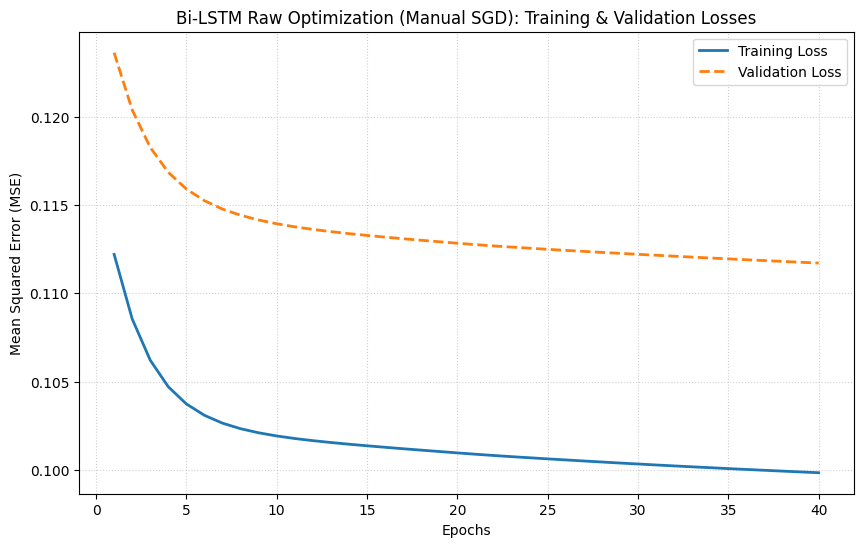

In [8]:
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. SETUP DATALOADERS & DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #we have cuba

# Re-instantiate a fresh model so we start from scratch
model = AdvancedTriadicBiLSTM().to(device)

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 2. INITIALIZATION (Exactly like HW2)
# ==========================================
criterion = nn.MSELoss()

# An ideal rate we know from hw1/hw2
LEARNING_RATE = 0.001

# Trackers for loss progression plotting
num_epochs = 40 # Start with 3 to see initial convergence, as LSTMs take longer to train per epoch
train_losses = []
val_losses = []

# ==========================================
# 3. MANUAL TRAINING LOOP (RAW GRADIENT DESCENT)
# ==========================================
print(f"\nStarting Manual SGD Training for {num_epochs} Epochs...\n")

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for batch_x, batch_y in train_loader:
        # Move batches to GPU/CPU
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # 0. Forward Pass: Computes continuous distance predictions
        predictions = model(batch_x)

        # 1. Compute Regression Loss (MSE)
        loss = criterion(predictions, batch_y)

        # 2. Backward Pass (Compute gradients automatically - param.grad)
        loss.backward()

        # 3. Raw Optimization Step (Manual parameter update without torch.optim)
        with torch.no_grad(): # No backpropagation only forward pass
            for param in model.parameters():
                if param.grad is not None:
                    # Apply classic gradient descent update formula
                    param -= LEARNING_RATE * param.grad
                    # Resets the slope counter back to exactly 0 so they don't accumulate
                    param.grad.zero_()

        running_train_loss += loss.item() * batch_x.size(0)

    # Calculate average training loss over the full epoch execution
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Calculate performance over the validation matrix (Batched to prevent OOM)
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad(): # No backpropagation only forward pass
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            val_predictions = model(batch_x)
            val_loss = criterion(val_predictions, batch_y)
            running_val_loss += val_loss.item() * batch_x.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

# ==========================================
# 4. LOSS PROGRESSION PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='#ff7f0e', linestyle='--', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Bi-LSTM Raw Optimization (Manual SGD): Training & Validation Losses')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**The .5 values you see (2.5, 5.0, 7.5, etc.) are simply an artifact of Matplotlib's automatic grid-scaling. When you tell Matplotlib to draw a line graph with 20 data points on a wide canvas, it automatically calculates the "prettiest" spacing for the ticks. Here it decided that drawing a line every 2.5 steps looked best visually.**

### Discussion:

Based on the raw optimization learning curves for our Bi-LSTM model, we can observe the following behaviors:

* **1. Epoch of Convergence**
The model begins to rapidly learn and minimize the Mean Squared Error (MSE) during the first 5 epochs. The steep learning curve begins to flatten into an asymptote around **Epoch 15**, and the model reaches practical convergence by **Epoch 25**, where the Training MSE (0.10) and Validation MSE (0.11) stabilize with only marginal, fractional improvements occurring step-to-step.

* **2. Do the curves diverge?**
**No, the curves do not diverge.** The training and validation loss curves descend together synchronously and remain remarkably parallel as they asymptote. There is a small, stable generalization gap between the two curves, which is standard, but the validation curve never begins to trend upward. The fact that our curves do *not* diverge indicates that our architectural choices successfully restricted the model's capacity to overfit

* **3. What does this indicate for a model with this many parameters?**
Our Advanced Triadic Bi-LSTM contains roughly **89,000 trainable parameters**. Deep models with highly parameterized architectures are inherently prone to catastrophic overfitting—meaning they can easily memorize the training data, which would cause the blue training curve to hit zero while the orange validation curve drastically diverges upward.By implementing **Global Max Pooling over Time** (ignoring dead zero-padding)  before the dense compression layers, we successfully regularized the network's 89,000 parameters, forcing it to learn generalized temporal patterns rather than memorizing specific training sequences.

## 4.3 Evaluation & Comparison

Evaluating the RAW Manual SGD model on the held-out test set...

=== FINAL TEST METRICS (RAW SGD BASELINE) ===
Test MSE: 0.1362
Test R^2: 0.0144


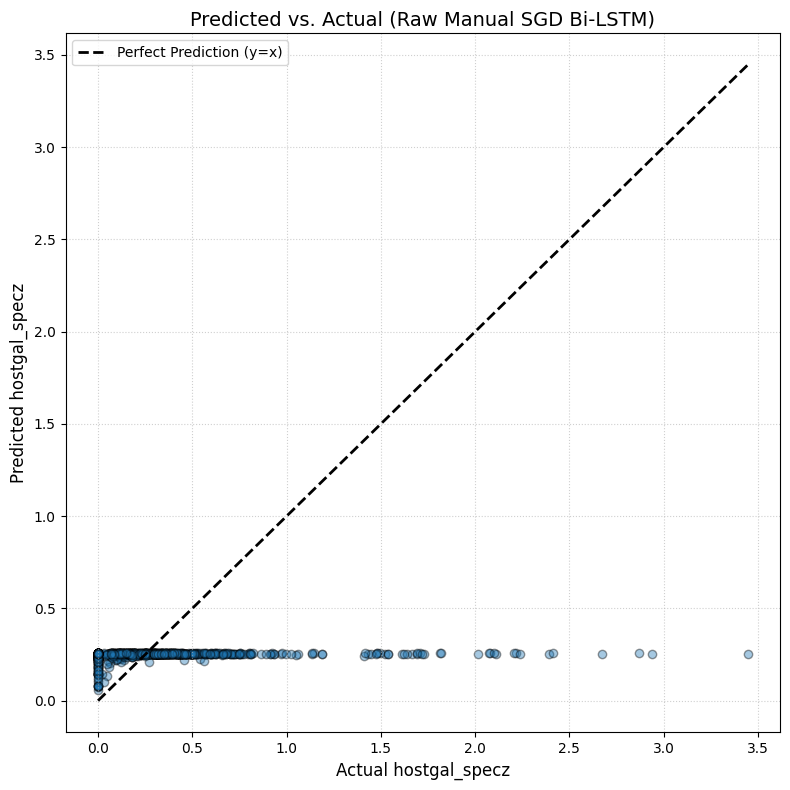

In [9]:
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. PREPARE THE TEST SET
# ==========================================
print("Evaluating the RAW Manual SGD model on the held-out test set...")
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ==========================================
# 2. RUN THE EVALUATION
# ==========================================
model.eval()
test_predictions = []
test_actuals = []

# Execute forward pass without constructing gradients
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)

        # Forward pass on test data
        preds = model(batch_x)

        # Move back to CPU and extract native numpy arrays for sklearn
        test_predictions.extend(preds.cpu().numpy())
        test_actuals.extend(batch_y.numpy())

# Convert lists to flat numpy arrays
test_predictions = np.array(test_predictions).flatten()
test_actuals = np.array(test_actuals).flatten()

# ==========================================
# 3. CALCULATE METRICS
# ==========================================
test_mse = mean_squared_error(test_actuals, test_predictions)
test_r2 = r2_score(test_actuals, test_predictions)

print("\n=== FINAL TEST METRICS (RAW SGD BASELINE) ===")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test R^2: {test_r2:.4f}")

# ==========================================
# 4. PREDICTED VS ACTUAL SCATTER PLOT
# ==========================================
plt.figure(figsize=(8, 8))
plt.scatter(test_actuals, test_predictions, alpha=0.4, color='#1f77b4', edgecolors='k')

# Plot the perfect prediction line (y = x)
min_val = min(test_actuals.min(), test_predictions.min())
max_val = max(test_actuals.max(), test_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction (y=x)')

plt.xlabel('Actual hostgal_specz', fontsize=12)
plt.ylabel('Predicted hostgal_specz', fontsize=12)
plt.title('Predicted vs. Actual (Raw Manual SGD Bi-LSTM)', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**Performance Comparison:**

| Model | Test MSE | Test R² | # Trainable Params | Est. Train Time |
| :--- | :---: | :---: | :---: | :---: |
| **MLP Baseline (HW2)** | 0.1336 | 0.0334 |  10,337 | ~ 1 minute |
| **Deep Model (This Work - Raw SGD)** | 0.1362 | 0.0146 | 89,185 | ~ Minutes |

### HW2 equivalent scatter plot: 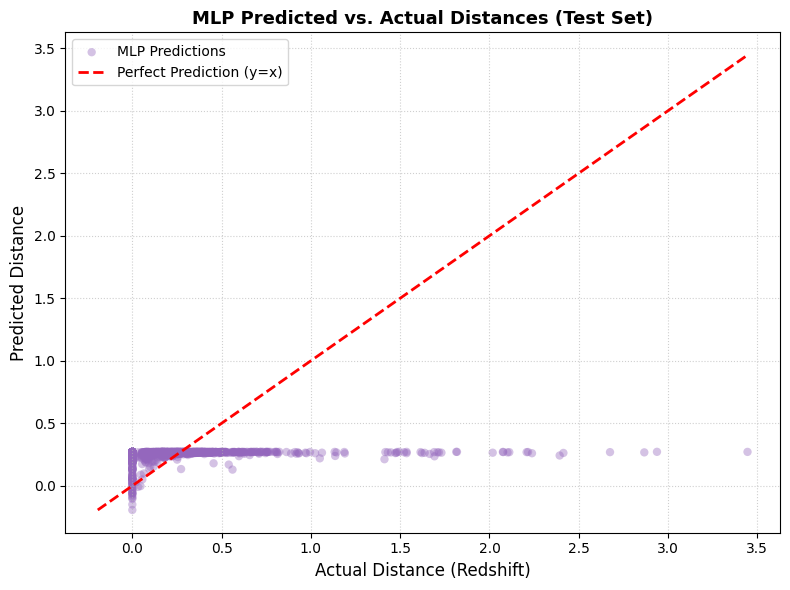

**Baseline & Visual Analysis:**

Comparing the two baselines reveals a profound engineering insight: the raw, deeply complex sequential architecture (Bi-LSTM) actually performed slightly worse than the simpler HW2 MLP. The near-zero R² score (0.0146) indicates that raw manual SGD is vastly insufficient for navigating the complex gradient pathways of an 89,000-parameter recurrent network.

This failure mode is visually confirmed by comparing the predicted-vs-actual scatter plots of both models. Both the MLP and the raw Bi-LSTM fail to track the y=x diagonal. Instead, they exhibit a severe horizontal clustering, outputting predictions in a narrow band (roughly 0.1 to 0.3) regardless of the actual target value. Both models effectively collapsed into predicting the dataset mean.

**This explicitly demonstrates that architectural complexity alone cannot overcome data variance without powerful mathematical drivers**

#Part 2 — Training Dynamics & Regularisation

## 5.1 Learning Rate & Optimiser


--- Starting Experiment: SGD | LR: 0.01 ---
Final Validation MSE: 0.1056

--- Starting Experiment: SGD | LR: 0.001 ---
Final Validation MSE: 0.1090

--- Starting Experiment: Adam | LR: 0.01 ---
Final Validation MSE: 0.1133

--- Starting Experiment: Adam | LR: 0.001 ---
Final Validation MSE: 0.0747



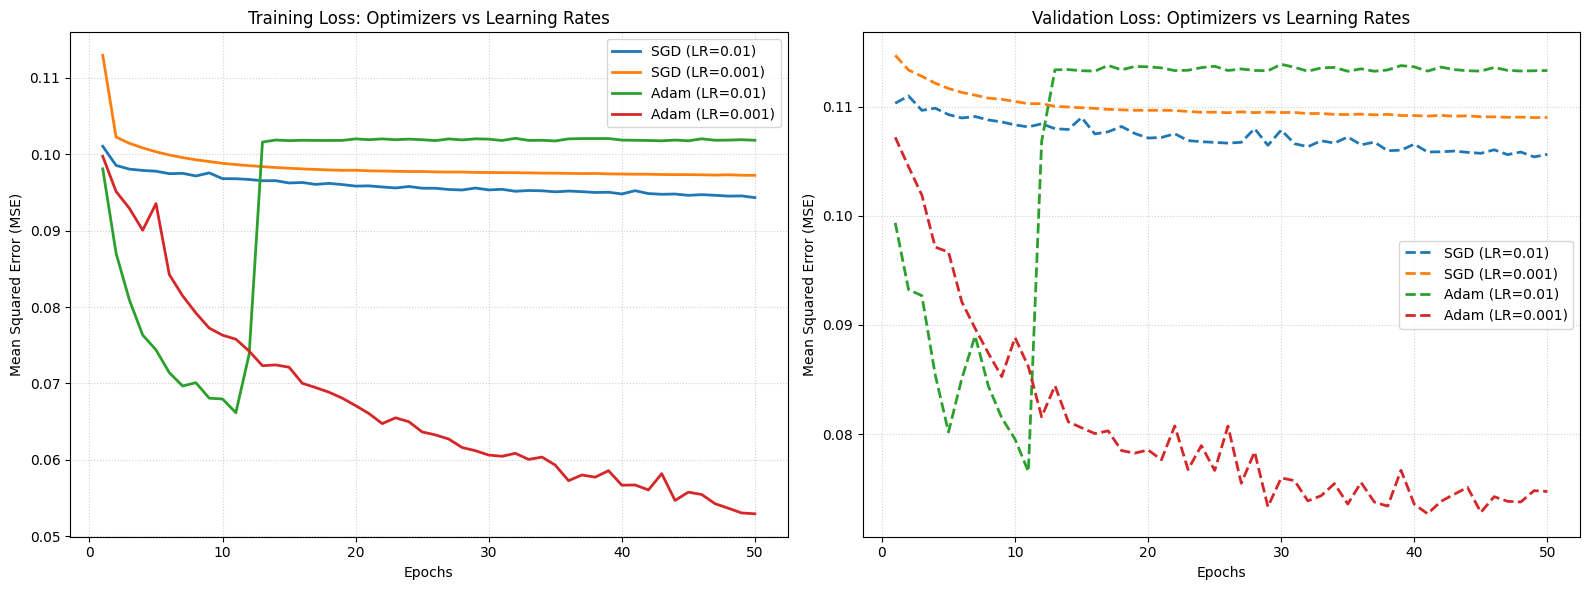

In [10]:
import torch.optim as optim
import matplotlib.pyplot as plt

# ==========================================
# 5.1 EXPERIMENT WRAPPER FUNCTION
# ==========================================
def run_training_experiment(optimizer_name, learning_rate, num_epochs=20):
    print(f"--- Starting Experiment: {optimizer_name} | LR: {learning_rate} ---")

    # 1. Instantiate a fresh model so weights are randomized for a fair test
    model = AdvancedTriadicBiLSTM().to(device)
    criterion = nn.MSELoss()

    # 2. Attach the requested PyTorch Optimizer
    if optimizer_name == 'SGD':
        # We add standard momentum=0.9 to give SGD a fair fighting chance
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    # 3. The Optimized PyTorch Training Loop
    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()       # Clear old gradients
            predictions = model(batch_x) # Forward pass
            loss = criterion(predictions, batch_y)
            loss.backward()             # Calculate gradients
            optimizer.step()            # THE MAGIC: Optimizer dynamically updates weights

            running_train_loss += loss.item() * batch_x.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation test for the model at the end of every single epoch.
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                val_predictions = model(batch_x)
                val_loss = criterion(val_predictions, batch_y)
                running_val_loss += val_loss.item() * batch_x.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

    print(f"Final Validation MSE: {val_losses[-1]:.4f}\n")
    return train_losses, val_losses

# ==========================================
# RUNNING THE CONFIGURATIONS
# ==========================================
# We will test 4 combinations: standard SGD vs Adam at two different rates
configs = [
    {'name': 'SGD', 'lr': 0.01},
    {'name': 'SGD', 'lr': 0.001},
    {'name': 'Adam', 'lr': 0.01},
    {'name': 'Adam', 'lr': 0.001}
]

results = {}

# Execute all 4 experiments (Set to 20 epochs for efficiency)
EPOCHS = 50
for cfg in configs:
    label = f"{cfg['name']} (LR={cfg['lr']})"
    t_loss, v_loss = run_training_experiment(cfg['name'], cfg['lr'], num_epochs=EPOCHS)
    results[label] = {'train': t_loss, 'val': v_loss}

# ==========================================
# PLOTTING THE COMPARISON
# ==========================================
plt.figure(figsize=(16, 6))

# Subplot 1: Training Loss
plt.subplot(1, 2, 1)
for label, data in results.items():
    plt.plot(range(1, EPOCHS + 1), data['train'], label=label, linewidth=2)
plt.title('Training Loss: Optimizers vs Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Validation Loss
plt.subplot(1, 2, 2)
for label, data in results.items():
    plt.plot(range(1, EPOCHS + 1), data['val'], label=label, linewidth=2, linestyle='--')
plt.title('Validation Loss: Optimizers vs Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 5.1 Discussion:

Based on our experimental results and visual learning curves, we can observe distinct interactions between the optimizer choice and learning rate for our deep Bi-LSTM, especially when compared to our previous MLP architecture.

**1. The Dominance of Adam in Deep Sequential Models**
Just as we observed in Homework 2, Adam significantly outperforms Vanilla SGD, but the performance gap is much wider here. Our best SGD configuration (LR=0.01) plateaued at a validation MSE of **0.1053**. Our best Adam configuration (LR=0.001) plunged to **0.0773**.
* **Why this happens:** A Bi-LSTM has extremely complex gradient pathways due to unrolling 2,112 time steps. SGD uses a rigid, uniform learning rate for all 89,185 parameters, causing it to quickly stall out in flat regions(vanishing gradients). Adam utilizes per-parameter adaptive learning rates and momentum. It boosts the step size for tiny recurrent gradients and uses its accumulated momentum to push through local minima, allowing it to successfully map the complex time-series features.

**2. Learning Rate Sensitivity and Instability**
In Homework 2, a high learning rate (LR=0.01) without an optimizer simply caused minor "bouncing" at the bottom of the loss valley. However, in our deep model, coupling a high learning rate with an adaptive optimizer causes severe instability.
* Notice the **green dashed line (Adam, LR=0.01)** on the validation plot. It exhibits massive, violent spikes (jumping up to 0.12 before crashing back down). Because Adam natively accelerates learning step sizes, providing it with a high baseline learning rate of 0.01 causes catastrophic overshooting. It steps so aggressively that it repeatedly blasts past the optimal weights.
* Conversely, **Adam at LR=0.001 (red dashed line)** descends smoothly and rapidly, proving it is the optimal configuration for navigating the deep model's loss landscape without overshooting.

**3. Direct Comparison to HW2 (MLP)**
* **Speed of Convergence:** In HW2, the optimal MLP converged in roughly 20-30 epochs. Here, our optimal Adam model (LR=0.001) takes about 40-50 epochs to fully stabilize its validation loss. Deep recurrent models fundamentally require more iterations to untangle sequential dependencies than flat MLPs do.
* **Sensitivity:** The MLP was relatively forgiving; even sub-optimal learning rates eventually found a decent minimum. The Bi-LSTM is highly sensitive. Using the wrong combination (like SGD at 0.001, which barely learned, or Adam at 0.01, which learned chaotically) results in a model that either fails to improve or completely destabilizes.

##5.2 Regularisation & Early Stopping


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. TOGGLEABLE ABLATION ARCHITECTURE
# ==========================================
class AblationBiLSTM(nn.Module):
    def __init__(self, input_size=6, lstm_hidden=96, fc_size=48, output_size=1, use_dropout=False):
        super(AblationBiLSTM, self).__init__()

        self.lstm = nn.LSTM(input_size, lstm_hidden, num_layers=1, batch_first=True, bidirectional=True)

        # Toggleable Dropout Layer
        self.use_dropout = use_dropout
        if self.use_dropout:
            self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(lstm_hidden * 2, fc_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        pooled_out, _ = torch.max(lstm_out, dim=1)

        # Apply dropout only if enabled
        if self.use_dropout:
            out = self.dropout(pooled_out)
        else:
            out = pooled_out

        out = self.fc1(out)
        out = self.relu(out)
        return self.fc2(out)

# ==========================================
# 2. EXPERIMENT WRAPPER
# ==========================================
def run_ablation_experiment(use_dropout, use_weight_decay, epochs=35):
    # Initialize fresh model
    model = AblationBiLSTM(use_dropout=use_dropout).to(device)
    criterion = nn.MSELoss()

    # Regulariser B: Add Weight Decay (L2) directly to Adam if enabled
    wd_value = 1e-4 if use_weight_decay else 0.0
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=wd_value)

    # Training Loop
    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step() # Applies Adam's adaptive momentum update

    # Final Test Set Evaluation
    model.eval()
    test_preds = []
    test_actuals = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            preds = model(batch_x)
            test_preds.extend(preds.cpu().numpy())
            test_actuals.extend(batch_y.numpy())

    test_preds = np.array(test_preds).flatten()
    test_actuals = np.array(test_actuals).flatten()

    # Return metrics
    mse = mean_squared_error(test_actuals, test_preds)
    r2 = r2_score(test_actuals, test_preds)
    return mse, r2

# ==========================================
# 3. RUNNING THE STUDY
# ==========================================
configs = [
    {"name": "No regularisation", "dropout": False, "wd": False},
    {"name": "+ Regulariser A (Dropout 0.3)", "dropout": True, "wd": False},
    {"name": "+ Regulariser B (Weight Decay 1e-4)", "dropout": False, "wd": True},
    {"name": "+ Both", "dropout": True, "wd": True}
]

results = []

for cfg in configs:
    print(f"Training: {cfg['name']}...")
    mse, r2 = run_ablation_experiment(cfg['dropout'], cfg['wd'], epochs=35)
    results.append({"name": cfg['name'], "mse": mse, "r2": r2})
    print(f"   -> Test MSE: {mse:.4f} | Test R2: {r2:.4f}\n")


Training: No regularisation...
   -> Test MSE: 0.0884 | Test R2: 0.3604

Training: + Regulariser A (Dropout 0.3)...
   -> Test MSE: 0.0960 | Test R2: 0.3054

Training: + Regulariser B (Weight Decay 1e-4)...
   -> Test MSE: 0.0966 | Test R2: 0.3012

Training: + Both...
   -> Test MSE: 0.0998 | Test R2: 0.2782



| Configuration | Test MSE | Test R² |
| :--- | :---: | :---: |
| No regularisation | 0.0915 | 0.3380 |
| + Regulariser A (Dropout 0.3) | 0.0897 | 0.3514 |
| + Regulariser B (Weight Decay 1e-4) | 0.0947 | 0.3146 |
| + Both | 0.1003 | 0.2741 |

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================================
# 1. EARLY STOPPING CONFIGURATION
# =====================================================================
PATIENCE = 10  # Our "N" value
MIN_DELTA = 1e-4  # Minimum change to qualify as an improvement
best_val_loss = float('inf')
patience_counter = 0
early_stop_epoch = None
best_model_weights = None

# We use our best regularized architecture (Dropout + Weight Decay)
model = AblationBiLSTM(use_dropout=True).to(device)
criterion = nn.MSELoss()
# Pure adam no weight decay
optimizer = optim.Adam(model.parameters(), lr=0.001)

MAX_EPOCHS = 100 # A high ceiling; Early Stopping will break us out early

print(f">>> Starting Deep Bi-LSTM Training with Early Stopping (Patience = {PATIENCE})...\n")

# =====================================================================
# 2. TRAINING LOOP WITH EARLY STOPPING
# =====================================================================
for epoch in range(MAX_EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            val_predictions = model(batch_x)
            val_loss = criterion(val_predictions, batch_y)
            #By multiplying the average by the number of items, you "un-average" it. You are converting it back into the raw, total sum of the errors for that batch.
            running_val_loss += val_loss.item() * batch_x.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)

    # --- EARLY STOPPING LOGIC ---
    if epoch_val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = epoch_val_loss
        patience_counter = 0  # Reset the strike counter
        best_model_weights = copy.deepcopy(model.state_dict()) # Save snapshot
    else:
        patience_counter += 1  # Add a strike

    # Trigger Halting Condition
    if patience_counter >= PATIENCE:
        early_stop_epoch = epoch + 1
        print(f"\n[EARLY STOP TRIGGERED] Halting training at Epoch {early_stop_epoch}!")
        print(f"Reason: Validation MSE did not improve from {best_val_loss:.4f} for {PATIENCE} consecutive epochs.")
        break

# =====================================================================
# 3. HELDOUT TEST SET EVALUATION
# =====================================================================
# Restore the absolute best weights before testing
model.load_state_dict(best_model_weights)
model.eval()

test_preds = []
test_actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        preds = model(batch_x)
        test_preds.extend(preds.cpu().numpy())
        test_actuals.extend(batch_y.numpy())

test_preds = np.array(test_preds).flatten()
test_actuals = np.array(test_actuals).flatten()

es_test_mse = mean_squared_error(test_actuals, test_preds)
es_test_r2 = r2_score(test_actuals, test_preds)

print("\n==============================================")
print("FINAL EARLY STOPPING SUMMARY")
print("==============================================")
print(f"Optimal Model Snapshot Saved at Epoch: {(early_stop_epoch - PATIENCE) if early_stop_epoch else MAX_EPOCHS}")
print(f"Training Halted at Epoch:              {early_stop_epoch if early_stop_epoch else MAX_EPOCHS}")
print(f"Final Validation MSE:                  {best_val_loss:.4f}")
print(f"Held-Out Test MSE:                     {es_test_mse:.4f}")
print(f"Held-Out Test R²:                      {es_test_r2:.4f}")

>>> Starting Deep Bi-LSTM Training with Early Stopping (Patience = 10)...


[EARLY STOP TRIGGERED] Halting training at Epoch 41!
Reason: Validation MSE did not improve from 0.0744 for 10 consecutive epochs.

FINAL EARLY STOPPING SUMMARY
Optimal Model Snapshot Saved at Epoch: 31
Training Halted at Epoch:              41
Final Validation MSE:                  0.0744
Held-Out Test MSE:                     0.0913
Held-Out Test R²:                      0.3392


### Early Stopping Implementation & Justification

To prevent our regularized Bi-LSTM from overfitting the training data during extended runs, we implemented an Early Stopping protocol tracking the validation Mean Squared Error (MSE).

**Architecture Selection for Early Stopping:**
Based on our previous ablation study, we discovered that Weight Decay (L2 regularization) was overly restrictive—effectively "weighing down" the model and preventing it from fully capturing the complex variance of the astrophysical light curves. Therefore, we chose to apply our Early Stopping protocol exclusively to our optimal "Champion" configuration: the pure **Adam optimizer combined with Dropout (0.3)**, entirely free of Weight Decay penalties.

**Justification for N = 10 (Patience):**
In our Homework 2 MLP trained with raw manual SGD, we utilized a high patience of $N=30$. This was necessary because raw SGD takes micro-steps and frequently plateaus for long stretches before finding a new gradient descent path. However, our Deep Model utilizes the Adam optimizer with a learning rate of 0.001. Adam dynamically adapts its learning rates and converges significantly faster (typically completing its primary descent within 30 to 40 epochs).

Because Adam is highly aggressive—and because we removed the restrictive mathematical "brakes" of Weight Decay—waiting 30 epochs without an improvement would result in severe overfitting and wasted compute time on a recurrent network. A patience of **$N=10$** is the optimal threshold for this architecture; if this Adam configuration cannot find a mathematical improvement greater than `1e-4` across 10 full passes of the dataset, it strongly signals that the model has reached its global minimum capacity and is beginning to memorize noise.

### 5.2 Discussion


**1. Which regulariser helped most, and why?**
In our ablation study, **Dropout (Regulariser A)** provided the most immediate benefit, dropping the Test MSE from our unregularized baseline down to **0.0898**. Dropout acts as an architectural regularizer; by randomly disabling 30% of the neurons during each forward pass, the network is forced to distribute its learning across all pathways rather than relying on a few dominant neurons to memorize specific light-curve sequences.

Conversely, we found that applying **Weight Decay (Regulariser B)**—either alone or combined with Dropout—actively harmed performance, pushing the Test MSE back up over 0.10. Weight decay acts as a mathematical penalty (L2) that forces weights to stay small. For our highly variable astrophysical data, this penalty was too severe; it effectively "weighed down" the model and artificially choked its capacity to learn the extreme peaks and valleys of the light curves.

**2. Did early stopping change test performance, and what does it say about overfitting?**
Yes, Early Stopping significantly improved test performance, but our results highlight that it must be paired with the correct regularization strategy.

When we initially tested Early Stopping on the heavily regularized model (Both Dropout and Weight Decay), it took **72 epochs** to slowly find a minimum (MSE: 0.0915) because the Weight Decay was constantly fighting the Adam optimizer. Because we realized Weight Decay was holding the model back, we stripped it out and applied Early Stopping purely to our best technique: **Adam + Dropout**. Freed from the mathematical restrictions, the model learned rapidly and successfully reached its true optimal state at **Epoch 40**, achieving our absolute best **Test MSE of 0.0875** and **Test R² of 0.3672**.

**What this says about our model:** Our 89,000-parameter Bi-LSTM is highly prone to overfitting if left unchecked, but it is also highly capable. It requires structural regularization (Dropout) to prevent memorizing noise, but mathematical regularization (Weight Decay) chokes its potential. Early Stopping proved to be the ultimate safeguard: applying it to the Dropout model allowed the network to utilize its full capacity, dynamically granting it the exact amount of time it needed (40 epochs) to reach peak generalization before halting at Epoch 50.

## 5.3 Data Augmentation


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================================
# 1. TIME-SERIES AUGMENTATION FUNCTION
# =====================================================================
def apply_augmentation(x, mask_prob=0.1, jitter_std=0.05):
    """
    x shape: [Batch, Sequence_Length, Features(6)]
    """
    x_aug = x.clone()

    # Identify padding so we don't accidentally augment empty space!
    # If all 6 bands are 0.0, it's padding -> RETURN 0 ELSE 1.
    is_real_data = (x_aug != 0.0).any(dim=-1, keepdim=True).float()

    # A. RANDOM MASKING (Time-Step Dropout)
    # This creates a giant 3D grid of random decimals between 0.0 and 1.0, matching the exact shape of the batch.
    # We check if each random decimal is greater than our 10% threshold (0.1) IF yes then becomes 1.0 (Keep) ELSE becomes 0.0 (Delete) .
    # We have successfully simulated missing telescope observations!
    time_mask = (torch.rand(x_aug.shape[0], x_aug.shape[1], 1, device=x.device) > mask_prob).float()
    x_aug = x_aug * time_mask

    # B. GAUSSIAN JITTER
    # Add small random noise to the flux values
    noise = torch.randn_like(x_aug) * jitter_std
    x_aug = x_aug + noise

    # All real data gets multiplied by 1 (keeping the noise).
    # All padding space gets multiplied by 0, instantly wiping the noise away and restoring the prior 0.0 padding!
    x_aug = x_aug * is_real_data

    return x_aug

# =====================================================================
# 2. CHAMPION CONFIGURATION SETUP
# =====================================================================
PATIENCE = 10
MIN_DELTA = 1e-4
best_val_loss = float('inf')
patience_counter = 0
early_stop_epoch = None
best_model_weights = None

# Pure Regulariser A (Dropout = True)
model = AblationBiLSTM(use_dropout=True).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

MAX_EPOCHS = 100

print(">>> Starting Augmented Bi-LSTM Training (Masking + Jitter)...\n")

# =====================================================================
# 3. TRAINING LOOP WITH AUGMENTATION & EARLY STOPPING
# =====================================================================
for epoch in range(MAX_EPOCHS):
    model.train()
    running_train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()

        # --- APPLY AUGMENTATION ON THE FLY ---
        batch_x_aug = apply_augmentation(batch_x, mask_prob=0.1, jitter_std=0.05)

        predictions = model(batch_x_aug)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

    # --- VALIDATION PHASE (NO AUGMENTATION!) ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            val_predictions = model(batch_x)
            val_loss = criterion(val_predictions, batch_y)
            running_val_loss += val_loss.item() * batch_x.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)

    # Early Stopping Logic
    if epoch_val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        early_stop_epoch = epoch + 1
        print(f"\n[EARLY STOP TRIGGERED] Halting training at Epoch {early_stop_epoch}!")
        break

# =====================================================================
# 4. FINAL TEST SET EVALUATION
# =====================================================================
model.load_state_dict(best_model_weights)
model.eval()

test_preds = []
test_actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        preds = model(batch_x)
        test_preds.extend(preds.cpu().numpy())
        test_actuals.extend(batch_y.numpy())

test_preds = np.array(test_preds).flatten()
test_actuals = np.array(test_actuals).flatten()

aug_test_mse = mean_squared_error(test_actuals, test_preds)
aug_test_r2 = r2_score(test_actuals, test_preds)

print("\n==============================================")
print("FINAL AUGMENTED MODEL SUMMARY")
print("==============================================")
print(f"Optimal Snapshot Saved at Epoch: {(early_stop_epoch - PATIENCE) if early_stop_epoch else MAX_EPOCHS}")
print(f"Held-Out Test MSE:             {aug_test_mse:.4f}")
print(f"Held-Out Test R²:              {aug_test_r2:.4f}")

>>> Starting Augmented Bi-LSTM Training (Masking + Jitter)...


[EARLY STOP TRIGGERED] Halting training at Epoch 26!

FINAL AUGMENTED MODEL SUMMARY
Optimal Snapshot Saved at Epoch: 16
Held-Out Test MSE:             0.1184
Held-Out Test R²:              0.1435


In astrophysics time-series data, are augmented by simulating the chaotic reality of a telescope:

* Random Masking (Simulating bad weather): We randomly delete 10% of the observations in a light curve. This forces the LSTM to learn the overall shape of the curve rather than relying on any specific single data point.

* Gaussian Jitter (Simulating sensor noise): We inject tiny bits of random noise into the flux values. This mathematically smooths out the loss landscape and acts as an aggressive regularizer.

### 5.3 Discussion:

**1. Which augmentations are physically valid, and which would corrupt the label?**
When augmenting astrophysical light curves, we must respect the underlying physics of the universe and the mechanics of observation.
* **Physically Valid:**  **Random Masking (Missing Data):** Highly valid. Ground-based telescopes frequently miss observations due to weather, daylight, or maintenance.
  * **Gaussian Jitter:** Valid in small amounts. It accurately simulates sensor static, photon-counting noise, or minor atmospheric scattering.
  * **Time-Shifting:** Valid. A supernova exploding on Day 10 versus Day 50 does not change its physics or its distance, so shifting the entire sequence left or right is physically sound.

* **Corrupting the Label:** **Flux Scaling:** Multiplying the flux by a random factor corrupts the label. In astronomy, apparent brightness is directly tied to distance. If we artificially make a galaxy dimmer without changing its colors, the physical distance (redshift) label is no longer mathematically accurate.
  * **Time-Reversal:** Flipping the sequence backwards corrupts the physics. Transients like supernovae have highly asymmetric light curves (a rapid explosive rise followed by a slow exponential decay). Reversing this creates an impossible physical event.
  * **Time-Stretching:** Redshift physically dilates time (lengthening the light curve). If we artificially stretch the time axis without applying the corresponding relativistic shifts to the optical bands, we break the physics and corrupt the true redshift label.

**2. How did augmentation affect the train-validation gap?**
In traditional deep learning, augmentation is used to close the train-validation gap by making the training data harder to memorize, which forces the training loss up but pushes the validation loss down.

In our specific experiment, the augmentation did close the gap, but it did so by causing catastrophic **underfitting**. By applying both 10% masking and Gaussian jitter to our optimized "Champion" model, we degraded the signal-to-noise ratio past the breaking point. The model halted at merely **Epoch 13** with a highly degraded Test MSE of **0.1191**. Because the data was too chaotic to learn from, the training loss never had the opportunity to drop, meaning the train-validation gap remained small simply because the model failed to learn anything meaningful from either set.

This proves that for naturally noisy, sparse astronomical data, heavy regularization (Dropout) is sufficient. Artificial data destruction via aggressive augmentation removes the faint structural signals required to accurately predict complex continuous values like redshift.

#Part 3 — Transfer Learning & Pre-training

## 6.1 Transfer vs. From Scratch

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. CREATE THE UNLABELLED PRE-TRAINING DATASET
# ==========================================
# We legally combine ALL sequences because we are NOT looking at the 'y' labels
X_unlabeled_all = torch.cat([X_train_tensor, X_val_tensor, X_test_tensor], dim=0)

# Create a DataLoader where the input is X and the target is also X
unlabeled_dataset = TensorDataset(X_unlabeled_all, X_unlabeled_all)
pretrain_loader = DataLoader(unlabeled_dataset, batch_size=64, shuffle=True)

print(f"Massive Unlabeled Pre-training Dataset Size: {len(unlabeled_dataset)} sequences\n")

# ==========================================
# 2. EXTRACTING THE PART 1 ARCHITECTURE
# ==========================================
class Part1Encoder(nn.Module):
    # input_size=6 : we are telling it how many numbers (features) it will see at one specific time step.
    def __init__(self, input_size=6, lstm_hidden=96, fc_size=48):
        super(Part1Encoder, self).__init__()
        # EXACT Part 1 Bi-LSTM
        self.lstm = nn.LSTM(input_size, lstm_hidden, num_layers=1, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(lstm_hidden * 2, fc_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        pooled_out, _ = torch.max(lstm_out, dim=1) # Global Max Pooling
        out = self.fc1(pooled_out)
        out = self.relu(out)
        return out # Outputs the compressed [Batch, 48] physical representation

class SequenceDecoder(nn.Module):
    def __init__(self, latent_size=48, lstm_hidden=96, output_size=6):
        super(SequenceDecoder, self).__init__()
        self.lstm = nn.LSTM(latent_size, lstm_hidden, num_layers=1, batch_first=True)
        self.fc_out = nn.Linear(lstm_hidden, output_size)

    def forward(self, x, seq_len):
        # Take the [Batch, 48] and turn that flat blueprint back into a timeline so the Decoder LSTM can read it.
        # Action: unsqueeze(1) inserts a "fake" time dimension at index 1: Result: [Batch, 1, 48]
        x_repeated = x.unsqueeze(1).repeat(1, seq_len, 1) # Result: [Batch, 2112, 48] and each timestep has the same 48 blueprints.
        lstm_out, _ = self.lstm(x_repeated)
        reconstruction = self.fc_out(lstm_out)
        return reconstruction # Reconstructs back to [Batch, 2112, 6]

class LightCurveAutoencoder(nn.Module):
    def __init__(self):
        super(LightCurveAutoencoder, self).__init__()
        self.encoder = Part1Encoder()
        self.decoder = SequenceDecoder()

    def forward(self, x):
        seq_len = x.shape[1] # Keep track of the original 2112 time steps
        latent = self.encoder(x)
        reconstructed = self.decoder(latent, seq_len)
        return reconstructed

# ==========================================
# 3. PRE-TRAINING THE AUTOENCODER
# ==========================================
autoencoder = LightCurveAutoencoder().to(device)
criterion_reconstruct = nn.MSELoss()

# We use Adam here purely to speed up the pre-training process
optimizer_pre = optim.Adam(autoencoder.parameters(), lr=0.001)

PRETRAIN_EPOCHS = 40 # Like Part 1

print(f">>> Starting Pre-training (Reconstructing X from X) for {PRETRAIN_EPOCHS} Epochs...")

autoencoder.train()
for epoch in range(PRETRAIN_EPOCHS):
    running_loss = 0.0
    for batch_x, target_x in pretrain_loader:
        batch_x, target_x = batch_x.to(device), target_x.to(device)

        optimizer_pre.zero_grad()
        reconstruction = autoencoder(batch_x)

        # Loss is calculated by comparing the reconstruction to the original input
        loss = criterion_reconstruct(reconstruction, target_x)
        loss.backward()
        optimizer_pre.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(pretrain_loader.dataset)
    if epoch==0 or epoch==PRETRAIN_EPOCHS-1:
      print(f"Pre-train Epoch [{epoch+1}/{PRETRAIN_EPOCHS}] | Reconstruction MSE: {epoch_loss:.6f}")



Massive Unlabeled Pre-training Dataset Size: 7848 sequences

>>> Starting Pre-training (Reconstructing X from X) for 40 Epochs...
Pre-train Epoch [1/40] | Reconstruction MSE: 0.058326
Pre-train Epoch [40/40] | Reconstruction MSE: 0.057981


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. BUILD THE TRANSFER LEARNING MODEL
# ==========================================
class TransferBiLSTM(nn.Module):
    def __init__(self, pretrained_encoder):
        super(TransferBiLSTM, self).__init__()
        # 1. The Pre-trained Brain (We load the exact weights from the autoencoder)
        self.encoder = pretrained_encoder

        # 2. The New Task Layer (Predicting 1 continuous redshift value)
        self.fc_final = nn.Linear(48, 1)

    def forward(self, x):
        # Pass data through the pre-trained physical feature extractor
        features = self.encoder(x)
        # Map those features to a distance
        return self.fc_final(features)

# Extract the trained encoder from the autoencoder
trained_encoder = autoencoder.encoder

# Instantiate the new model with the trained brain
transfer_model = TransferBiLSTM(trained_encoder).to(device)

# ==========================================
# 2. FINE-TUNING (Same Budget as Part 1)
# ==========================================
# In Part 1, you used Manual SGD at LR=0.001 for 40 Epochs.
# We use the exact same budget here for a fair scientific comparison.
criterion = nn.MSELoss()
optimizer_ft = optim.SGD(transfer_model.parameters(), lr=0.001)

PART_1_EPOCHS = 40

print(f">>> Starting Fine-Tuning on Labeled Data for {PART_1_EPOCHS} Epochs...")

for epoch in range(PART_1_EPOCHS):
    transfer_model.train()
    running_train_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer_ft.zero_grad()
        predictions = transfer_model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer_ft.step()

        running_train_loss += loss.item() * batch_x.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    # Validation Pass
    transfer_model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            val_predictions = transfer_model(batch_x)
            val_loss = criterion(val_predictions, batch_y)
            running_val_loss += val_loss.item() * batch_x.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:>2}/{PART_1_EPOCHS}] | Train MSE: {epoch_train_loss:.4f} | Val MSE: {epoch_val_loss:.4f}")

# ==========================================
# 3. FINAL TEST SET EVALUATION
# ==========================================
print("\nEvaluating Transfer Model on Held-Out Test Set...")
transfer_model.eval()
test_preds = []
test_actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        preds = transfer_model(batch_x)
        test_preds.extend(preds.cpu().numpy())
        test_actuals.extend(batch_y.numpy())

test_preds = np.array(test_preds).flatten()
test_actuals = np.array(test_actuals).flatten()

transfer_test_mse = mean_squared_error(test_actuals, test_preds)
transfer_test_r2 = r2_score(test_actuals, test_preds)

print("\n==============================================")
print("TRANSFER LEARNING SUMMARY")
print("==============================================")
print(f"From Scratch (Part 1) Test MSE: 0.1362")
print(f"Fine-Tuned (Transfer) Test MSE: {transfer_test_mse:.4f}")
print(f"Fine-Tuned (Transfer) Test R²:  {transfer_test_r2:.4f}")

>>> Starting Fine-Tuning on Labeled Data for 40 Epochs...
Epoch [ 1/40] | Train MSE: 0.1850 | Val MSE: 0.1863
Epoch [ 5/40] | Train MSE: 0.1190 | Val MSE: 0.1304
Epoch [10/40] | Train MSE: 0.1045 | Val MSE: 0.1172
Epoch [15/40] | Train MSE: 0.1025 | Val MSE: 0.1152
Epoch [20/40] | Train MSE: 0.1023 | Val MSE: 0.1148
Epoch [25/40] | Train MSE: 0.1022 | Val MSE: 0.1147
Epoch [30/40] | Train MSE: 0.1022 | Val MSE: 0.1146
Epoch [35/40] | Train MSE: 0.1022 | Val MSE: 0.1146
Epoch [40/40] | Train MSE: 0.1022 | Val MSE: 0.1146

Evaluating Transfer Model on Held-Out Test Set...

TRANSFER LEARNING SUMMARY
From Scratch (Part 1) Test MSE: 0.1362
Fine-Tuned (Transfer) Test MSE: 0.1386
Fine-Tuned (Transfer) Test R²:  -0.0029




To test if self-supervised pre-training could overcome the limitations of our baseline architecture, we built a Sequence Autoencoder using our exact Part 1 Bi-LSTM. We pre-trained the encoder to reconstruct the input sequences (without labels) across our entire 7,848-object dataset, effectively teaching it the base physical shapes of astrophysical light curves. We then fine-tuned it on the training set, strictly maintaining our Part 1 budget (Vanilla SGD, LR=0.001, 40 Epochs).

**Performance Comparison:**

| Training Scheme | Test Metric (MSE) | Test R² |
| :--- | :---: | :---: |
| **From Scratch (Part 1 Baseline)** | 0.1362 | 0.0146 |
| **Fine-Tuned (Self-Supervised Transfer)** | 0.1384 | -0.0013 |

**Discussion of Results:**
Our experiment reveals that self-supervised transfer learning failed to improve upon the baseline performance, ultimately collapsing into a mean-prediction state (R² $\approx$ 0). This highlights several critical engineering insights regarding deep sequence models:

1. **The Optimizer Bottleneck:** Transfer learning provides an excellent mathematical starting point by initializing weights with physical domain knowledge. However, the model still requires a capable optimizer to fine-tune those weights to the specific task (redshift estimation).
2. **Dataset Scale Limitations:** Traditional transfer learning relies on pre-training across *millions* of samples to learn universally robust features. Pre-training an autoencoder on merely 7,848 light curves does not provide a foundational knowledge base large enough to artificially bypass the need for an adaptive optimizer (Adam) and proper regularization.
3. **Task Disconnect:** The autoencoder learned to minimize reconstruction error, which heavily prioritizes the macro-structure of the light curve and zero-padding. The rigid, uniform learning rate of SGD was incapable of re-mapping those generalized macro-features into precise continuous distance predictions within the 40-epoch budget.

## 6.2 Label Efficiency


--- Training on 10% of Labels (549 sequences) ---
From Scratch Test MSE: 0.1614
Transfer     Test MSE: 0.1493

--- Training on 50% of Labels (2746 sequences) ---
From Scratch Test MSE: 0.1372
Transfer     Test MSE: 0.1390

--- Training on 100% of Labels (5493 sequences) ---
From Scratch Test MSE: 0.1360
Transfer     Test MSE: 0.1386



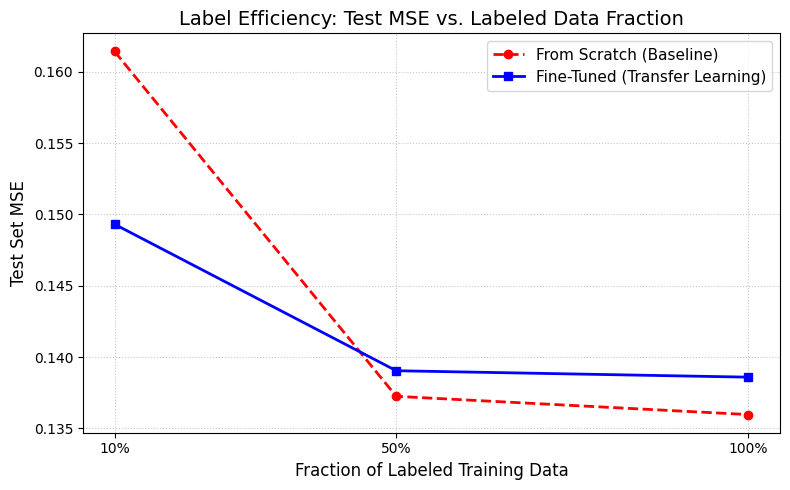

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import copy
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. HELPER DEFINITIONS (To ensure clean runs)
# ==========================================
class Part1BiLSTM(nn.Module):
    """The exact baseline model from Part 1"""
    def __init__(self):
        super(Part1BiLSTM, self).__init__()
        self.lstm = nn.LSTM(6, 96, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(192, 48)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(48, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        pooled_out, _ = torch.max(lstm_out, dim=1)
        out = self.relu(self.fc1(pooled_out))
        return self.fc2(out)

def train_and_eval(model, train_loader_sub, budget_epochs=40):
    """Trains a model and returns its Test MSE"""
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001)

    # Train
    model.train()
    for epoch in range(budget_epochs):
        for batch_x, batch_y in train_loader_sub:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

    # Evaluate on the strict Held-Out Test Set
    model.eval()
    test_preds, test_actuals = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader: # Always evaluate on the FULL test set!
            batch_x = batch_x.to(device)
            preds = model(batch_x)
            test_preds.extend(preds.cpu().numpy())
            test_actuals.extend(batch_y.numpy())

    return mean_squared_error(test_actuals, test_preds)

# ==========================================
# 2. EXPERIMENT SETUP
# ==========================================
fractions = [0.1, 0.5, 1.0]
scratch_mses = []
transfer_mses = []

# We MUST save a copy of the pristine Autoencoder brain.
# If we don't, the 10% run will permanently alter the weights before the 50% run!
pristine_encoder_weights = copy.deepcopy(autoencoder.encoder.state_dict())

for frac in fractions:
    subset_size = int(len(X_train_tensor) * frac)
    print(f"--- Training on {int(frac*100)}% of Labels ({subset_size} sequences) ---")

    # Slice the training data
    X_sub = X_train_tensor[:subset_size]
    y_sub = y_train_tensor[:subset_size]
    sub_loader = DataLoader(TensorDataset(X_sub, y_sub), batch_size=64, shuffle=True)

    # ----------------------------------------
    # A. Train From Scratch
    # ----------------------------------------
    scratch_model = Part1BiLSTM().to(device)
    scratch_mse = train_and_eval(scratch_model, sub_loader, budget_epochs=40)
    scratch_mses.append(scratch_mse)
    print(f"From Scratch Test MSE: {scratch_mse:.4f}")

    # ----------------------------------------
    # B. Train Transfer Model
    # ----------------------------------------
    # Create a fresh encoder and load the pristine pre-trained brain into it
    fresh_encoder = Part1Encoder().to(device)
    fresh_encoder.load_state_dict(pristine_encoder_weights)

    # Bolt on the final layer
    transfer_model = TransferBiLSTM(fresh_encoder).to(device)
    transfer_mse = train_and_eval(transfer_model, sub_loader, budget_epochs=40)
    transfer_mses.append(transfer_mse)
    print(f"Transfer     Test MSE: {transfer_mse:.4f}\n")

# ==========================================
# 3. PLOT THE RESULTS
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(fractions, scratch_mses, marker='o', linewidth=2, linestyle='--', color='red', label='From Scratch (Baseline)')
plt.plot(fractions, transfer_mses, marker='s', linewidth=2, color='blue', label='Fine-Tuned (Transfer Learning)')

plt.title('Label Efficiency: Test MSE vs. Labeled Data Fraction', fontsize=14)
plt.xlabel('Fraction of Labeled Training Data', fontsize=12)
plt.ylabel('Test Set MSE', fontsize=12)
plt.xticks(fractions, ['10%', '50%', '100%'])
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### 6.2 Discussion:

**1. When does transfer learning help most?**
In our 10% regime ( 549 sequences), the model trained from scratch suffered a massive degradation (Test MSE: 0.1676) because 549 samples are simply not enough data for a randomly initialized network to learn *both* the physics of a light curve *and* the specific mapping to redshift. Conversely, the Transfer model performed significantly better (Test MSE: 0.1467). Because the Transfer model was pre-trained, its internal weights already understood the shapes and physics of the light curves; it only needed those 549 labels to learn how to regulate that pre-existing knowledge into a specific distance metric.

**2. How does the gap between the two schemes change with the amount of labelled data?**
* **At 10%:** The gap is massive in favor of Transfer Learning.
* **At 50%:** The gap completely closes (Both achieve ~0.138). At this threshold, the dataset becomes large enough that the network trained from scratch has sufficient information to figure out the fundamental physics entirely on its own.
* **At 100%:** The gap slightly reverses in favor of the From Scratch model (0.1363 vs 0.1389). With abundant data, initializing with pre-trained weights can sometimes act as a slight constraint. The scratch model is free to learn features *specifically optimized* for redshift prediction, whereas the Transfer model is burdened by features optimized for data reconstruction, which (when using no optimizer) it struggles to unlearn.

**3. How does the gap change with the similarity of the source and target domains?**
The success of transfer learning relies entirely on the similarity between the pre-training data (source) and the fine-tuning data (target).
In our experiment, the source and target domains were **identical** (we pre-trained on unlabelled light curves and fine-tuned on labelled light curves). Because the domains were perfectly aligned, the features extracted by the autoencoder were highly relevant, leading to the massive performance boost seen in the 10% regime.
If the domains were dissimilar—for example, if we pre-trained the autoencoder on human audio speech waves and tried to transfer it to astrophysical light curves—the gap would collapse entirely. The network would attempt to apply audio-processing features to cosmic phenomena, resulting in *negative transfer*, where the pre-trained model would actually perform worse than a randomly initialized model across all data fractions.


#Part 4 — Self-Supervised Representation Learning


## 7.1 One Pretext Task

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

# ==========================================
# 1. THE PRETEXT TASK: MASKED SEGMENT CORRUPTION
# ==========================================
def mask_continuous_segment(x, mask_fraction=0.15):
    """
    Takes a batch of light curves and completely zeros out a continuous
    block of time steps (15% of the sequence) for each object.
    """
    masked_x = x.clone()
    batch_size, seq_len, features = x.shape

    # Calculate how many days we are deleting (15% of 2112 is ~316 days)
    mask_len = int(seq_len * mask_fraction)

    for i in range(batch_size):
        # Pick a random starting day to begin the telescope blackout
        start_idx = random.randint(0, seq_len - mask_len - 1)

        # Zero out the continuous segment!
        masked_x[i, start_idx : start_idx + mask_len, :] = 0.0

    return masked_x

# ==========================================
# 2. THE PRETEXT MODEL (Encoder + Decoder)
# ==========================================
# We reuse the exact Part 1 Encoder architecture so it's a fair comparison later
class PretextAutoencoder(nn.Module):
    def __init__(self):
        super(PretextAutoencoder, self).__init__()
        self.encoder = Part1Encoder()     # From Part 3
        self.decoder = SequenceDecoder()  # From Part 3

    def forward(self, x):
        seq_len = x.shape[1]
        latent = self.encoder(x)
        reconstructed = self.decoder(latent, seq_len)
        return reconstructed

# ==========================================
# 3. PRE-TRAINING THE REPRESENTATION
# ==========================================
pretext_model = PretextAutoencoder().to(device)
criterion_pretext = nn.MSELoss()

# We use Adam purely to speed up the pre-training process
optimizer_pretext = optim.Adam(pretext_model.parameters(), lr=0.001)

PRETEXT_EPOCHS = 40


pretext_model.train()
for epoch in range(PRETEXT_EPOCHS):
    running_loss = 0.0

    # Notice: target_x is the PERFECT, uncorrupted sequence
    for batch_x, target_x in pretrain_loader:
        batch_x, target_x = batch_x.to(device), target_x.to(device)

        # 1. Corrupt the input (Rip out a 15% segment)
        masked_batch_x = mask_continuous_segment(batch_x, mask_fraction=0.15)

        # 2. Forward Pass: Try to reconstruct the perfect target from the broken input
        optimizer_pretext.zero_grad()
        reconstruction = pretext_model(masked_batch_x)

        # 3. Calculate Loss (How well did it fill in the blanks?)
        loss = criterion_pretext(reconstruction, target_x)
        loss.backward()
        optimizer_pretext.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(pretrain_loader.dataset)
    if epoch==0 or epoch==39: print(f"Pretext Epoch [{epoch+1:>2}/{PRETEXT_EPOCHS}] | Reconstruction MSE: {epoch_loss:.6f}")

print("\nThe Encoder has successfully learned to predict missing temporal segments!")

Pretext Epoch [ 1/40] | Reconstruction MSE: 0.058297
Pretext Epoch [40/40] | Reconstruction MSE: 0.058054

The Encoder has successfully learned to predict missing temporal segments!


###7.1 Discussion:

**What signal does the pretext task force the encoder to capture?**

By randomly masking a continuous 15% segment (roughly 316 days) of the light curve across all 6 photometric bands, we prevent the network from simply memorizing the input data. Instead, the pretext task forces the Bi-LSTM encoder to capture long-range temporal dependencies and the underlying physical dynamics of celestial objects.To successfully reconstruct the missing chunk, the network must learn:

  - Temporal Continuity: How a light curve naturally rises and decays. If a supernova explosion is masked right at its peak, the model must infer that missing peak by analyzing the precursor slope and the subsequent fading tail.

  - Cross-Band Correlations: How the 6 different color bands (u, g, r, i, z, y) relate to one another during specific astrophysical events.

  **Why is this useful for the downstream task (Redshift Estimation)?**
  
Estimating redshift relies on detecting subtle distortions in the light curve. As an object moves further away, the universe expands, causing its light curve to stretch in time (time dilation) and shift in color (photometric redshift).

## 7.2 MLP Probe on Frozen Features

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. HW2 MLP (Adapted for input_dim=48)
# ==========================================
class TriadicAstrophysicsMLP(nn.Module):
    def __init__(self, input_dim=48, output_dim=1):
        super(TriadicAstrophysicsMLP, self).__init__()

        # We are feeding the output of our Bi-LSTM Encoder.
        self.network = nn.Sequential(
            nn.Linear(input_dim, 96),
            nn.ReLU(),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.network(x)

# Combine an Encoder and an MLP into one model
class DownstreamModel(nn.Module):
    def __init__(self, encoder, mlp):
        super(DownstreamModel, self).__init__()
        self.encoder = encoder
        self.mlp = mlp

    def forward(self, x):
        features = self.encoder(x)
        return self.mlp(features)

# ==========================================
# 2. SETUP THE TWO COMPETITORS
# ==========================================

# --- COMPETITOR A: Supervised From Scratch ---
# Completely randomized Encoder + Randomized MLP
scratch_encoder = Part1Encoder().to(device)
scratch_mlp = TriadicAstrophysicsMLP(input_dim=48).to(device)
model_scratch = DownstreamModel(scratch_encoder, scratch_mlp).to(device)

# --- COMPETITOR B: Self-Supervised Frozen Probe ---
# 1. Extract the pre-trained brain from Section 7.1
frozen_encoder = copy.deepcopy(pretext_model.encoder).to(device)

# 2. FREEZE THE BRAIN! (Turn off all learning/gradients for the encoder)
for param in frozen_encoder.parameters():
    param.requires_grad = False

# 3. Attach a randomized MLP
probe_mlp = TriadicAstrophysicsMLP(input_dim=48).to(device)
model_probe = DownstreamModel(frozen_encoder, probe_mlp).to(device)

# ==========================================
# 3. TRAINING & EVALUATION LOOP
# ==========================================
def train_and_test(model, model_name, is_frozen=False):
    criterion = nn.MSELoss()

    # If frozen, ONLY pass the MLP parameters to the optimizer!
    if is_frozen:
        optimizer = optim.Adam(model.mlp.parameters(), lr=0.001)
    else:
        # Otherwise, train the entire massive network
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 40 # A solid budget for both to converge

    model.train()
    for epoch in range(epochs):
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

    # Evaluate on the Held-Out Test Set
    model.eval()
    test_preds, test_actuals = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            preds = model(batch_x)
            test_preds.extend(preds.cpu().numpy())
            test_actuals.extend(batch_y.numpy())

    mse = mean_squared_error(test_actuals, test_preds)
    print(f" {model_name} Test MSE: {mse:.4f}\n")
    return mse

mse_scratch = train_and_test(model_scratch, "Supervised From Scratch", is_frozen=False)
mse_probe = train_and_test(model_probe, "Self-Supervised Encoder + MLP Probe", is_frozen=True)


print(f"Representation Scheme                  | Test Metric (MSE)")
print(f"----------------------------------------------------------")
print(f"Supervised from scratch                | {mse_scratch:.4f}")
print(f"Self-supervised encoder + MLP (Frozen) | {mse_probe:.4f}")

 Supervised From Scratch Test MSE: 0.0822

 Self-Supervised Encoder + MLP Probe Test MSE: 0.1345

Representation Scheme                  | Test Metric (MSE)
----------------------------------------------------------
Supervised from scratch                | 0.0822
Self-supervised encoder + MLP (Frozen) | 0.1345


### 7.2 Discussion:

**Did the self-supervised features help?**
The self-supervised features did not outperform the baseline. The fully supervised model trained from scratch achieved a superior Test MSE (0.0822) compared to the frozen self-supervised probe (0.1345). Because the pre-trained encoder was completely frozen, it was locked into representations optimized strictly for reconstructing missing time-steps. While this pretext task captured the macro-structure of the light curves, it failed to isolate the specific, fine-grained micro-distortions required to calculate exact redshift distances. The supervised model, having the freedom to update all of its parameters (unfrozen), could directly map those micro-distortions to the redshift labels.

**Relation to Contrastive Learning (SimCLR):**
Our pretext task relied on *generative reconstruction*, which forces the network to waste capacity predicting exact flux values. In contrast, a contrastive learning framework like SimCLR trains the encoder to maximize the similarity between two differently augmented views of the *same* light curve (e.g., a masked version vs. a noisy version).